In [6]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# Importing csvs and correcting data types

orders_qu = pd.read_csv("orders_qu.csv")
orders_qu['created_date'] = pd.to_datetime(orders_qu['created_date'])
orderlines_qu = pd.read_csv("orderlines_qu.csv")
orderlines_qu['date'] = pd.to_datetime(orderlines_qu['date'])
product_category_cl = pd.read_csv("products_category.csv")
brands_cl = pd.read_csv("brands_cl.csv")    

In [8]:

# Adding additional info into orderlines data frame
product_category_cl["sku_short"] = product_category_cl["sku"].str[0:3]
product_category_cl = product_category_cl.merge(brands_cl, left_on="sku_short", right_on="short", how="left")
product_category_cl["long"] = product_category_cl["long"].fillna("Unknown")
product_category_cl = product_category_cl.rename(columns={"long": "brand"})

orderlines_subset = orderlines_qu[["sku", "date", "product_quantity", "unit_price"]]
products_subset = product_category_cl[["sku", "brand", "price", "sub_category", "category"]]

discount_df = orderlines_subset.merge(products_subset, on="sku", how="inner")
discount_df["revenue"] = discount_df["unit_price"] * discount_df["product_quantity"]
discount_df["discount"] = discount_df["price"] - discount_df["unit_price"]
discount_df["total_discount"] = discount_df["discount"] * discount_df["product_quantity"]
discount_df["percentage_discount"] = 100 * discount_df["discount"] / discount_df["price"]

## How Many Products Are Being Discounted?

In [9]:
# Total unique products in the dataset
total_skus = discount_df['sku'].nunique()

# % of discount (order lines) on Products sold
discounted_skus = discount_df.loc[discount_df['discount'] > 0, 'sku'].nunique()
pct_skus_discounted = 100 * discounted_skus / total_skus

# % of discount (order lines) on sales
total_transactions = len(discount_df)
discounted_transactions = (discount_df['discount'] > 0).sum()
pct_transactions_discounted = 100 * discounted_transactions / total_transactions

print(f"Products discounted: {discounted_skus} / {total_skus} ({pct_skus_discounted:.1f}%)")
print(f"Transactions discounted: {discounted_transactions} / {total_transactions} ({pct_transactions_discounted:.1f}%)")

Products discounted: 4906 / 5098 (96.2%)
Transactions discounted: 49404 / 53231 (92.8%)



| Metric | Value | What It Tells Us |
|---|---|---|
| % of full catalog ever discounted | **49.1%** (4,906 / 9,992 SKUs) |  *listed* catalog with discounting — diluted by products that never sold at all |
| % of *sold* products ever discounted | **96.2%** (4,906 / 5,098 SKUs) | discount among products that actually sold |
| % of transactions discounted | **92.8%** (49,404 / 53,231 order lines) |  discount involved at the point of purchases |


# How big are these discounts, as a percentage of price?

In [10]:
# Descriptive stats on discount depth, transaction-level
discounted_lines = discount_df[discount_df["discount"] > 0]
discounted_lines["percentage_discount"].describe()

count    49404.000000
mean        23.239168
std         17.332621
min          0.001391
25%         11.107510
50%         19.543536
75%         29.974987
max         97.140815
Name: percentage_discount, dtype: float64

In [12]:
total_skus = product_category_cl["sku"].nunique()
discounted_skus = discounted_lines["sku"].nunique()
pct_discounted = 100 * discounted_skus / total_skus

print(f"Total SKUs: {total_skus}")
print(f"Discounted SKUs: {discounted_skus}")
print(f"% of catalog ever discounted: {pct_discounted:.1f}%")

Total SKUs: 9992
Discounted SKUs: 4906
% of catalog ever discounted: 49.1%


In [13]:
bins = [0, 10, 20, 30, 50, 100]
labels = ["0-10%", "10-20%", "20-30%", "30-50%", "50%+"]
discounted_lines["discount_band"] = pd.cut(discounted_lines["percentage_discount"], bins=bins, labels=labels)

discount_band_counts = discounted_lines["discount_band"].value_counts().sort_index()
discount_band_pct = 100 * discount_band_counts / len(discounted_lines)

pd.DataFrame({"transactions": discount_band_counts, "% of discounted sales": discount_band_pct.round(1)})

,transactions,% of discounted sales
discount_band,,
0-10%,10506,21.3
10-20%,15186,30.7
20-30%,11430,23.1
30-50%,7307,14.8
50%+,4975,10.1


In [14]:
sku_avg_discount = discounted_lines.groupby("sku")["percentage_discount"].mean()
sku_avg_discount.describe()

count    4906.000000
mean       22.675604
std        15.712771
min         0.002747
25%        11.371803
50%        19.059780
75%        29.801828
max        89.768883
Name: percentage_discount, dtype: float64

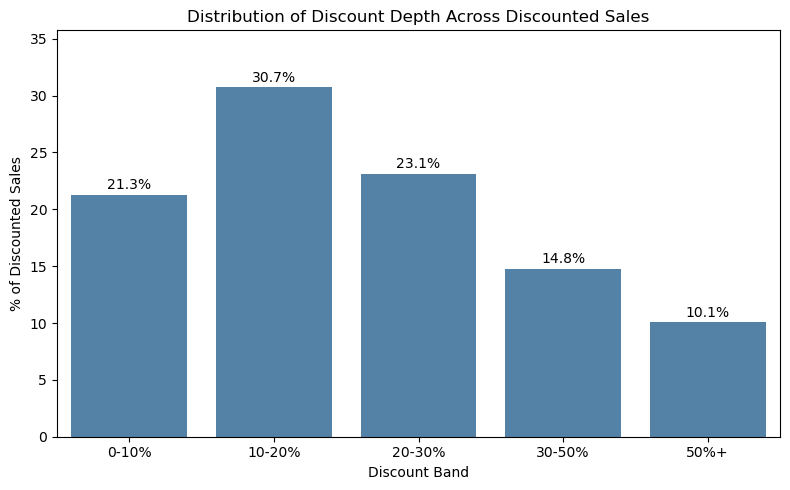

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=discount_band_pct.index, y=discount_band_pct.values, color="steelblue")

plt.title("Distribution of Discount Depth Across Discounted Sales")
plt.xlabel("Discount Band")
plt.ylabel("% of Discounted Sales")

# Add percentage labels on top of each bar
for i, v in enumerate(discount_band_pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

plt.ylim(0, max(discount_band_pct.values) + 5)
plt.tight_layout()
plt.show()

* The 10–20% discount band is the most common, accounting for 30.7% of all discounted sales.
* Over half (53.8%) of discounted sales fall between 10% and 30% discounts (30.7% + 23.1%).
* High discounts (50%+) are relatively rare, representing only 10.1% of discounted sales.
* This suggests the business rarely resorts to steep, fire-sale-level discounts
  
**(10–30% discount is the dominant pattern across the vast majority of sales**

# How do seasonality and special dates (Christmas, Black Friday) affect sales?

In [16]:
daily_sales = orders_qu.groupby(orders_qu["created_date"].dt.date).agg(
    daily_revenue=("total_paid", "sum"),
    daily_orders=("order_id", "count")
).reset_index()

daily_sales.head()

,created_date,daily_revenue,daily_orders
0,2017-01-01,16787.31,96
1,2017-01-02,38348.05,285
2,2017-01-03,36147.11,262
3,2017-01-04,17034.17,115
4,2017-01-05,12641.24,126


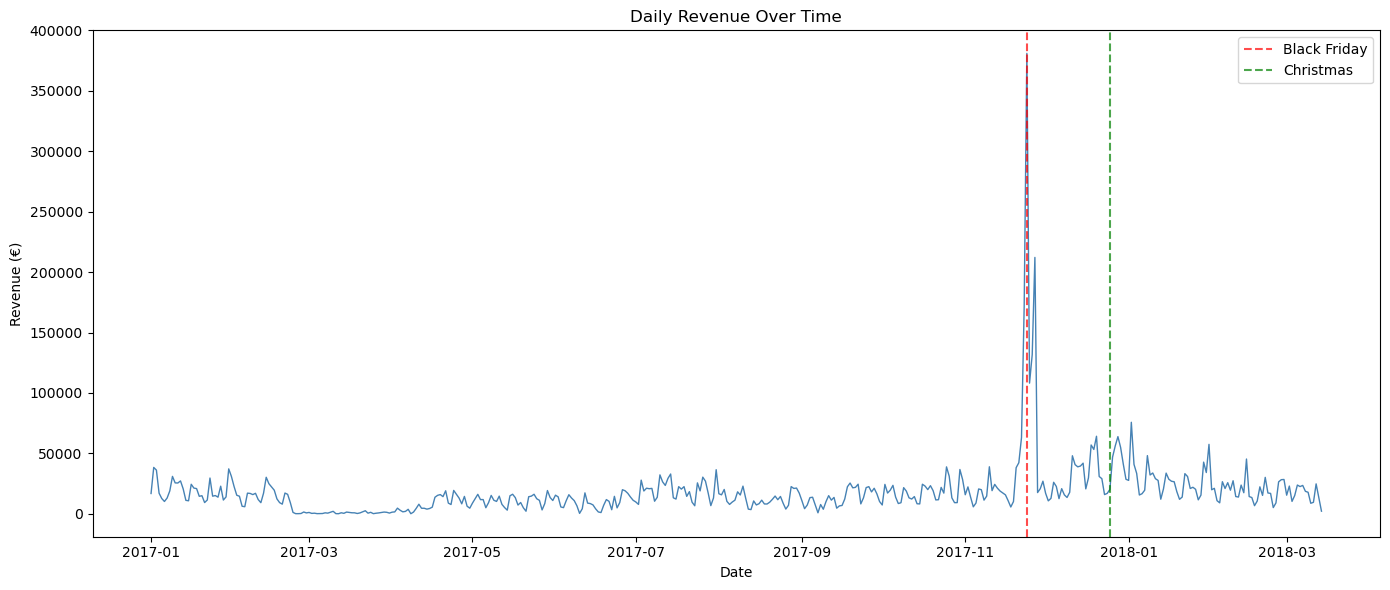

In [17]:
daily_sales["created_date"] = pd.to_datetime(daily_sales["created_date"])

plt.figure(figsize=(14, 6))
plt.plot(daily_sales["created_date"], daily_sales["daily_revenue"], color="steelblue", linewidth=1)

# Mark key dates - adjust years based on your data's date range
black_fridays = pd.to_datetime(["2017-11-24", "2018-11-23"])
christmases = pd.to_datetime(["2017-12-25", "2018-12-25"])

for bf in black_fridays:
    if daily_sales["created_date"].min() <= bf <= daily_sales["created_date"].max():
        plt.axvline(bf, color="red", linestyle="--", alpha=0.7, label="Black Friday" if bf == black_fridays[0] else "")

for xmas in christmases:
    if daily_sales["created_date"].min() <= xmas <= daily_sales["created_date"].max():
        plt.axvline(xmas, color="green", linestyle="--", alpha=0.7, label="Christmas" if xmas == christmases[0] else "")

plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue (€)")
plt.legend()
plt.tight_layout()
plt.show()

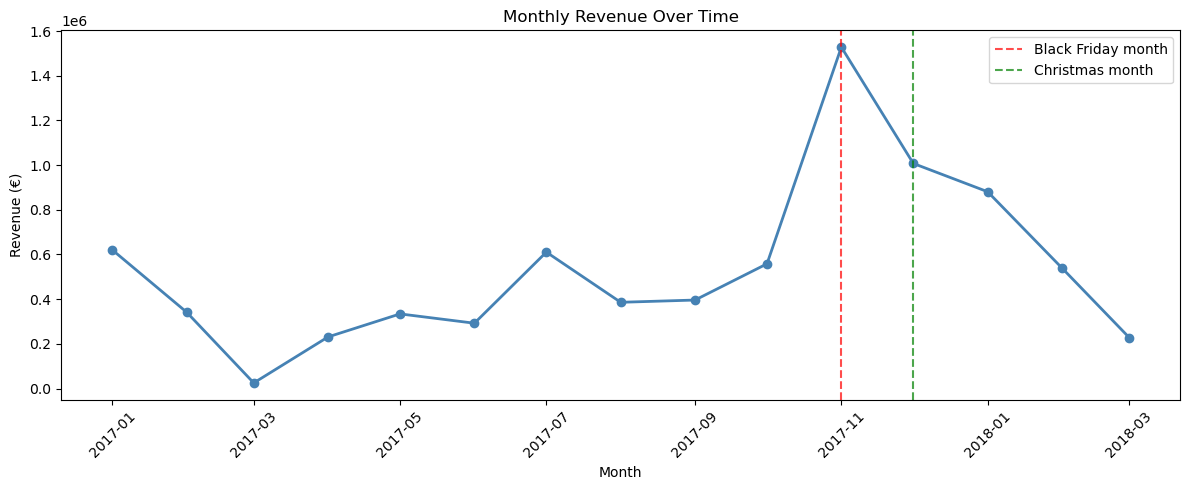

In [18]:
orders_qu["month"] = orders_qu["created_date"].dt.to_period("M")
monthly_sales = orders_qu.groupby("month").agg(
    monthly_revenue=("total_paid", "sum"),
    monthly_orders=("order_id", "count")
).reset_index()

monthly_sales["month"] = monthly_sales["month"].dt.to_timestamp()  # convert Period -> datetime, not string

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["month"], monthly_sales["monthly_revenue"], marker="o", color="steelblue", linewidth=2)

plt.axvline(pd.to_datetime("2017-11-01"), color="red", linestyle="--", alpha=0.7, label="Black Friday month")
plt.axvline(pd.to_datetime("2017-12-01"), color="green", linestyle="--", alpha=0.7, label="Christmas month")

plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue (€)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Define the Christmas-to-New Year window
orders_qu["is_christmas_week"] = orders_qu["created_date"].between("2017-12-20", "2018-01-01")
orderlines_qu["is_christmas_week"] = orderlines_qu["date"].between("2017-12-20", "2018-01-01")
discount_df["is_christmas_week"] = discount_df["date"].between("2017-12-20", "2018-01-01")

# Build a single period label so "rest of year" properly excludes both events
def label_period(date):
    if pd.Timestamp("2017-11-20") <= date <= pd.Timestamp("2017-11-27"):
        return "Black Friday week"
    elif pd.Timestamp("2017-12-20") <= date <= pd.Timestamp("2018-01-01"):
        return "Christmas-New Year"
    else:
        return "Rest of year"

orders_qu["period"] = orders_qu["created_date"].apply(label_period)
orderlines_qu["period"] = orderlines_qu["date"].apply(label_period)
discount_df["period"] = discount_df["date"].apply(label_period)

# Order-level comparison
order_summary = orders_qu.groupby("period").agg(
    order_count=("order_id", "count"),
    avg_order_value=("total_paid", "mean")
).round(2)

# Basket size comparison
basket_summary = orderlines_qu.groupby(["period", "id_order"])["product_quantity"].sum().reset_index()
basket_summary = basket_summary.groupby("period")["product_quantity"].mean().round(2)

# Discount depth comparison
discount_summary = discount_df.loc[discount_df["discount"] > 0].groupby("period")["percentage_discount"].mean().round(2)

order_summary["avg_items_per_order"] = basket_summary
order_summary["avg_discount_pct"] = discount_summary

order_summary

,order_count,avg_order_value,avg_items_per_order,avg_discount_pct
period,,,,
Black Friday week,3565,262.55,1.56,23.38
Christmas-New Year,2365,198.12,1.37,23.20
Rest of year,35055,187.54,1.46,23.23


## Black Friday vs. Christmas–New Year — Comparing Seasonal Events

| Metric | Black Friday Week (8 days) | Christmas–New Year (13 days) | Rest of Year |
|---|---|---|---|
| Order count | 3,565 | 2,365 | 35,055 |
| Avg order value | €262.55 | €198.12 | €187.54 |
| Avg items per order | 1.56 | 1.37 | 1.46 |
| Avg discount % | 23.38% | 23.20% | 23.23% |

* Black Friday: a sharp surge — high order volume, larger baskets, and higher order values, all within 8-day window.
* Christmas–New Year: a more moderate, sustained uplift in order count, with basket size and order value close to (or slightly below) the yearly baseline.
* In both periods, discount depth stays essentially flat vs. the rest of the year (~23%).
* Seasonal spike is not driven by promotional discounting — it appears to be demand-driven events

In [20]:
orderlines_expanded = orderlines_qu.merge(
    product_category_cl[["sku", "price", "sub_category", "category"]],
    on="sku", how="inner"
)

orderlines_expanded["revenue"] = orderlines_expanded["unit_price"] * orderlines_expanded["product_quantity"]
orderlines_expanded["discount"] = orderlines_expanded["price"] - orderlines_expanded["unit_price"]
orderlines_expanded["percentage_discount"] = 100 * orderlines_expanded["discount"] / orderlines_expanded["price"]

In [21]:
plot_data = (
    orderlines_expanded
    .resample("D", on="date")
    .agg({
        "percentage_discount": "mean",
        "id_order": "nunique"
    })
    .reset_index()
)

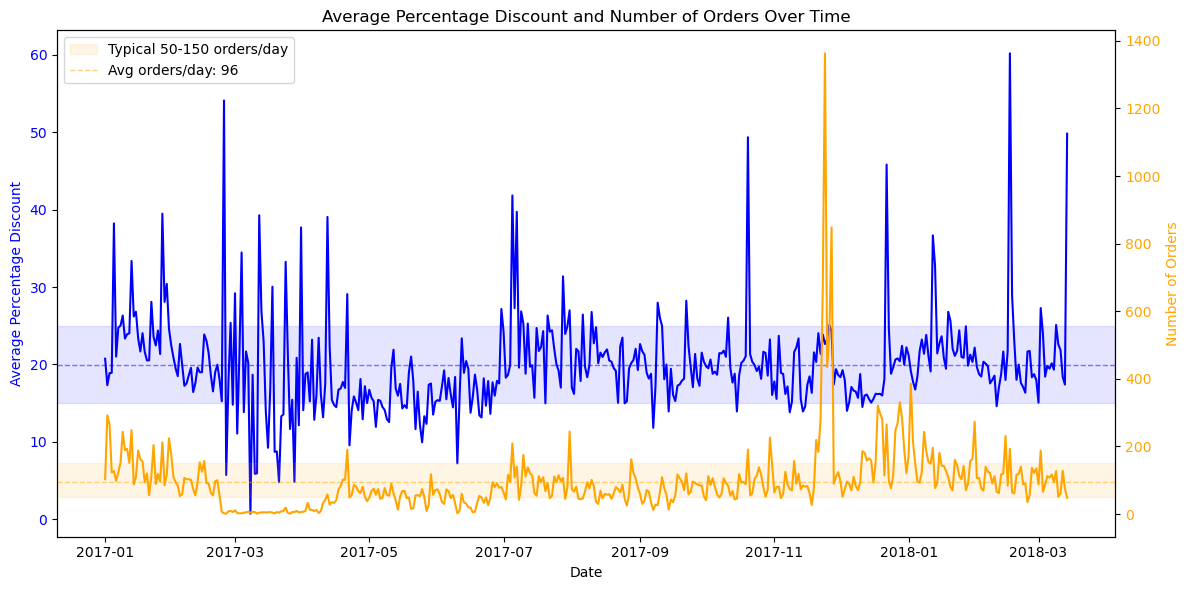

In [22]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=plot_data, x="date", y="percentage_discount", ax=ax1, color="blue")
ax1.set_ylabel("Average Percentage Discount", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Shade the 15-25% discount band
ax1.axhspan(15, 25, color="blue", alpha=0.1)

# Mean discount reference line
mean_discount = plot_data["percentage_discount"].mean()
ax1.axhline(mean_discount, color="blue", linestyle="--", alpha=0.5, linewidth=1)

ax2 = ax1.twinx()
sns.lineplot(data=plot_data, x="date", y="id_order", ax=ax2, color="orange")
ax2.set_ylabel("Number of Orders", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# Shade the typical 50-150 orders/day baseline band
ax2.axhspan(50, 150, color="orange", alpha=0.1, label="Typical 50-150 orders/day")

# Mean order count reference line
mean_orders = plot_data["id_order"].mean()
ax2.axhline(mean_orders, color="orange", linestyle="--", alpha=0.5, linewidth=1, label=f"Avg orders/day: {mean_orders:.0f}")

ax1.set_xlabel("Date")
ax1.set_title("Average Percentage Discount and Number of Orders Over Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

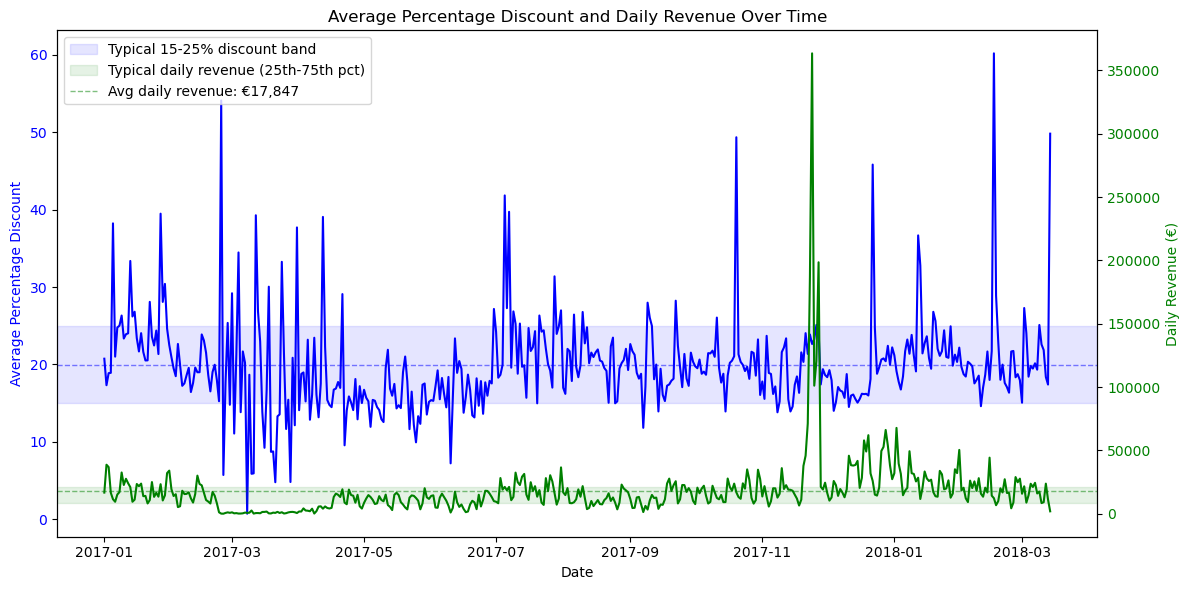

In [23]:
plot_data_rev = (
    orderlines_expanded
    .resample("D", on="date")
    .agg({
        "percentage_discount": "mean",
        "revenue": "sum"
    })
    .reset_index()
)

mean_discount = plot_data_rev["percentage_discount"].mean()
mean_revenue = plot_data_rev["revenue"].mean()

rev_q25 = plot_data_rev["revenue"].quantile(0.25)
rev_q75 = plot_data_rev["revenue"].quantile(0.75)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=plot_data_rev, x="date", y="percentage_discount", ax=ax1, color="blue")
ax1.set_ylabel("Average Percentage Discount", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.axhspan(15, 25, color="blue", alpha=0.1, label="Typical 15-25% discount band")
ax1.axhline(mean_discount, color="blue", linestyle="--", alpha=0.5, linewidth=1)

ax2 = ax1.twinx()
sns.lineplot(data=plot_data_rev, x="date", y="revenue", ax=ax2, color="green")
ax2.set_ylabel("Daily Revenue (€)", color="green")
ax2.tick_params(axis="y", labelcolor="green")
ax2.axhspan(rev_q25, rev_q75, color="green", alpha=0.1, label=f"Typical daily revenue (25th-75th pct)")
ax2.axhline(mean_revenue, color="green", linestyle="--", alpha=0.5, linewidth=1, label=f"Avg daily revenue: €{mean_revenue:,.0f}")

ax1.set_xlabel("Date")
ax1.set_title("Average Percentage Discount and Daily Revenue Over Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
category_summary = product_category_cl.groupby("category")["sku"].count().sort_values(ascending=False)
category_summary

category
Storage & Memory                  2401
Apple Devices                     1869
Protection & Cases                1826
Other                              951
Connectivity, Power & Charging     870
Networking & Smart Home            631
Accessories                        498
Audio                              346
Services & Parts                   323
Input Devices                      253
Software                            24
Name: sku, dtype: int64

# How should products be classified into different categories to simplify reports and analysis?

In [25]:
subcategory_summary = product_category_cl.groupby(["category", "sub_category"])["sku"].count().sort_values(ascending=False)
subcategory_summary

category                        sub_category         
Protection & Cases              iPhone/iPad Case         1441
Storage & Memory                NAS / Network Storage     975
Other                           Other                     951
Storage & Memory                Hard Drive                667
Apple Devices                   Mac Desktop               658
Networking & Smart Home         Smart Home / Gadgets      466
Apple Devices                   Mac Laptop                449
Storage & Memory                SSD                       370
Protection & Cases              MacBook Case              269
Connectivity, Power & Charging  Adapters / Hubs           260
                                Power Bank / Charger      259
                                Cable                     256
Storage & Memory                RAM / Memory              216
Apple Devices                   iPhone                    207
                                Monitor                   191
Accessories     

# Do higher discounts actually increase revenue

* Correlation — e.g., does daily/product-level discount % correlate with daily/product-level revenue?
* discounts by category, since "higher discounts increase revenue" could be true for some product types and false for others.

In [26]:
# Daily-level
daily_metrics = (
    orderlines_expanded
    .resample("D", on="date")
    .agg({"percentage_discount": "mean", "revenue": "sum"})
    .reset_index()
)
daily_correlation = daily_metrics["percentage_discount"].corr(daily_metrics["revenue"])

# Product-level
product_metrics = (
    orderlines_expanded
    .groupby("sku")
    .agg({"percentage_discount": "mean", "revenue": "sum"})
    .reset_index()
)
product_correlation = product_metrics["percentage_discount"].corr(product_metrics["revenue"])

print(f"Daily-level correlation: {daily_correlation:.3f}")
print(f"Product-level correlation: {product_correlation:.3f}")

Daily-level correlation: 0.086
Product-level correlation: -0.125


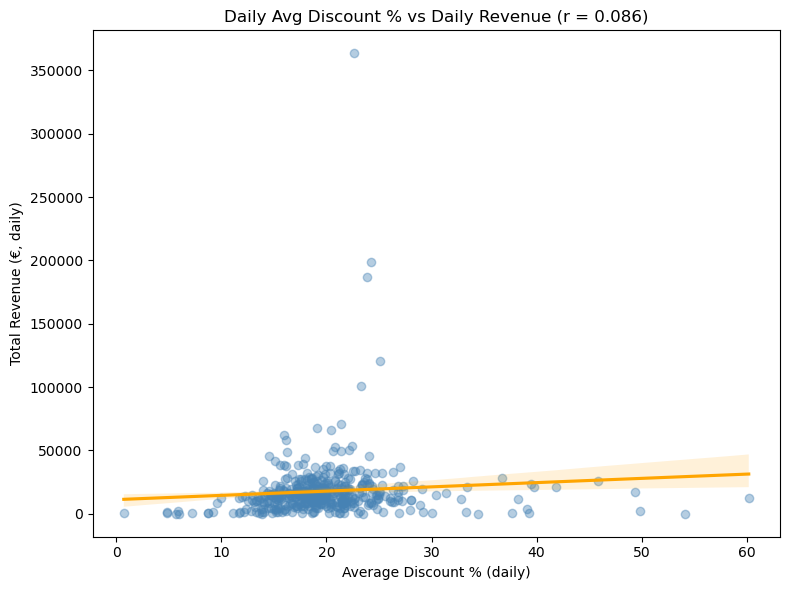

In [27]:
# Daily-level scatter (discount % vs revenue)
plt.figure(figsize=(8, 6))
sns.regplot(data=daily_metrics, x="percentage_discount", y="revenue",
            scatter_kws={"alpha": 0.4, "color": "steelblue"}, line_kws={"color": "orange"})
plt.title(f"Daily Avg Discount % vs Daily Revenue (r = {daily_correlation:.3f})")
plt.xlabel("Average Discount % (daily)")
plt.ylabel("Total Revenue (€, daily)")
plt.tight_layout()
plt.show()

**Observation:**
* Discount depth shows almost no relationship with daily revenue (r = 0.086), indicating that higher discounts do not directly drive higher sales.
* Most days cluster around 10–30% discounts with moderate revenue, while the highest revenue spike occurred at a normal ~22% discount.
* Revenue peaks appear to be driven by factors like order volume or promotional events rather than deeper discounts.

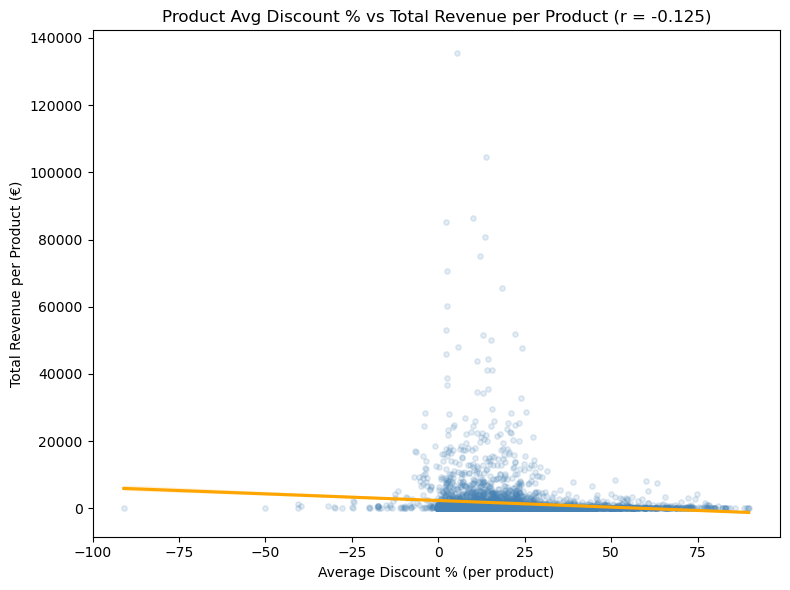

In [41]:
# Product-level scatter (discount % vs revenue)
plt.figure(figsize=(8, 6))
sns.regplot(data=product_metrics, x="percentage_discount", y="revenue",
            scatter_kws={"alpha": 0.15, "color": "steelblue", "s": 15}, line_kws={"color": "orange"})
plt.title(f"Product Avg Discount % vs Total Revenue per Product (r = {product_correlation:.3f})")
plt.xlabel("Average Discount % (per product)")
plt.ylabel("Total Revenue per Product (€)")
plt.tight_layout()
plt.show()

**Observation:**
* Product-level discounting shows no relationship with revenue (r = -0.125); higher discounts do not lead to higher revenue.
* Top revenue-generating products typically fall within the 0–25% discount range, while heavily discounted products generate low revenue.
Product revenue appears to be driven by factors other than discount depth.

In [34]:
category_correlation = (
    orderlines_expanded
    .groupby(["category", "sku"])
    .agg({"percentage_discount": "mean", "revenue": "sum"})
    .reset_index()
    .groupby("category")
    .apply(lambda g: g["percentage_discount"].corr(g["revenue"]))
    .sort_values(ascending=False)
)
category_correlation

category
Software                          0.205703
Services & Parts                  0.193448
Accessories                       0.032646
Networking & Smart Home           0.011704
Protection & Cases               -0.010232
Audio                            -0.010646
Input Devices                    -0.059569
Storage & Memory                 -0.060321
Other                            -0.086679
Connectivity, Power & Charging   -0.111595
Apple Devices                    -0.191017
dtype: float64

/var/folders/7w/jz3l_mz572s2bn9h0b6d8_qc0000gn/T/ipykernel_7184/2380028634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_correlation.values, y=category_correlation.index, palette=colors)


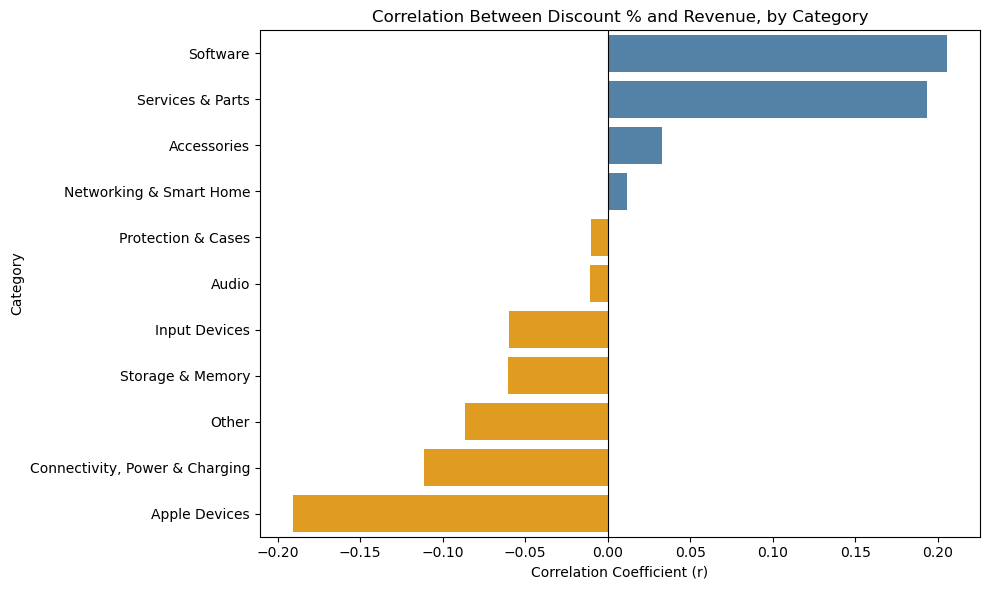

In [38]:
plt.figure(figsize=(10, 6))
colors = ["steelblue" if v > 0 else "orange" for v in category_correlation.values]
sns.barplot(x=category_correlation.values, y=category_correlation.index, palette=colors)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation Between Discount % and Revenue, by Category")
plt.xlabel("Correlation Coefficient (r)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

The discount line (blue) hovers around average 15-25% discount for most of the ~15-month period. 
The order count line (orange) shows roughly 50-150 orders/day through the year and the seasonal pattern - Black Friday spike in November 2017

# What is the distribution of product prices across different categories?

In [35]:
price_by_category = product_category_cl.groupby("category")["price"].describe().round(2)
price_by_category.sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Apple Devices,1869.0,2245.28,2269.04,29.95,719.00,1639.00,2969.00,15339.00
Storage & Memory,2401.0,737.16,961.64,3.79,138.98,422.56,985.97,10212.99
Software,24.0,353.39,357.03,49.99,85.24,290.25,435.45,1599.90
Other,951.0,290.47,529.18,5.95,39.99,89.00,279.94,4249.00
Input Devices,253.0,239.38,518.44,4.90,34.90,69.99,149.00,3199.90
Audio,346.0,167.20,133.50,3.49,89.00,131.97,199.95,799.00
Networking & Smart Home,631.0,137.20,158.51,2.99,49.95,99.00,159.99,1499.00
"Connectivity, Power & Charging",870.0,87.57,149.97,3.99,25.00,39.99,84.21,1881.99
Accessories,498.0,70.76,78.35,7.99,34.95,52.99,69.95,899.00


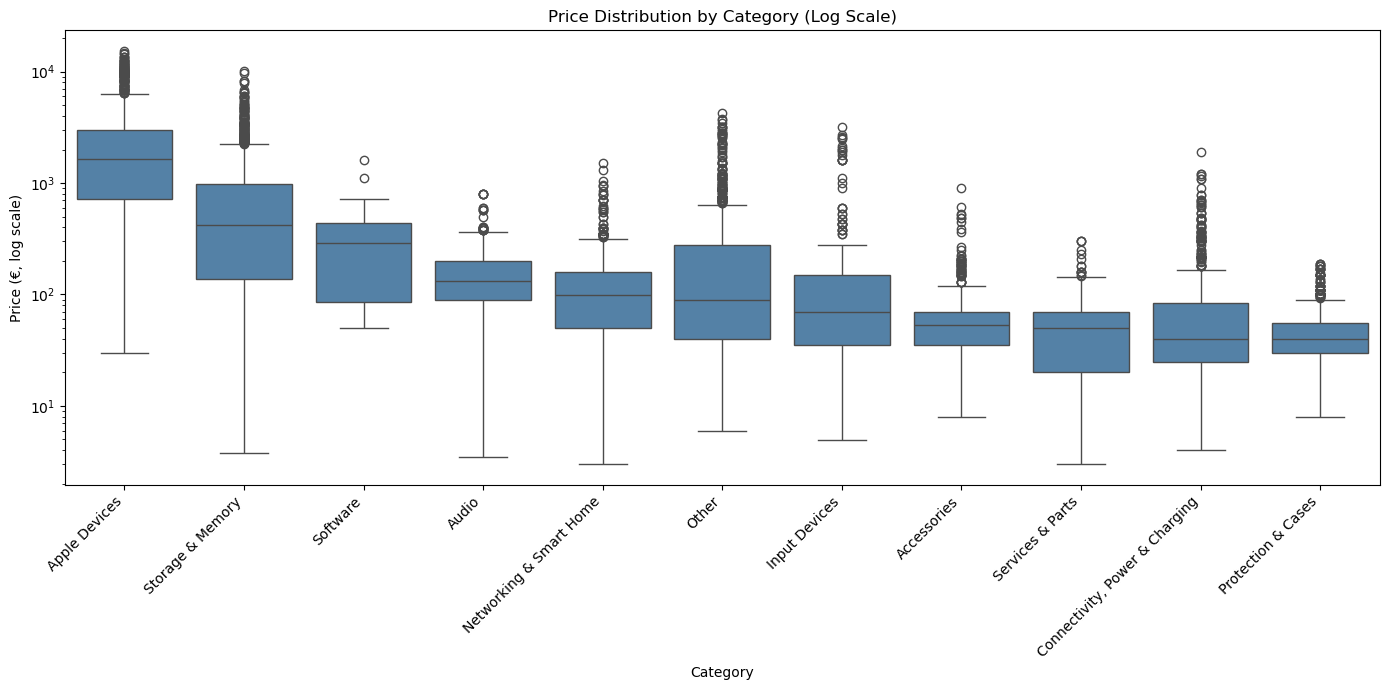

In [39]:
plt.figure(figsize=(14, 7))
order = product_category_cl.groupby("category")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=product_category_cl, x="category", y="price", order=order, color="steelblue")

plt.yscale("log")
plt.title("Price Distribution by Category (Log Scale)")
plt.xlabel("Category")
plt.ylabel("Price (€, log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# How could data collection be improved?

* promo_price was corrupted — decimal-shifted by roughly 10x
* type was a numeric code with no lookup table
* No timestamp on price changes 

# Executive Summary: Discount Strategy Analysis

## What the Data Shows

**Discounting is not occasional — it's the default state of the business.**
- 96.2% of products that actually sold were discounted at least once; 92.8% of all individual transactions involved a discount versus catalog price.
- The typical discount: median depth is 19.5%, mean 23.2% is consistent whether measured per transaction or per product.
- A quarter of all discounted sales involve markdowns of 30% or more; 1 in 10 exceed 50% off.

**Seasonality pattern**
The data shows:
* Seasonal(Black Friday week/Christmas/New Year): 23.38% average discount
* Rest of the year: 23.23% average discount
  
The average discount remains unchanged throughout the year. This indicates that Eniac does not rely on deeper markdowns during major sales events. Seasonal revenue spikes are more likely driven by higher customer demand, increased order volumes, larger basket sizes, and purchases of higher-value products, rather than more aggressive discounting.

**Business Implications:**

Since an average discount of approximately 23% is the business's steady-state pricing strategy—not a seasonal exception—every additional order is, on average, already sold at a significant markdown. Increasing sales volume alone does not necessarily translate into proportional revenue growth.

## Recommendation 
The analysis supports the Board's concern about the long-term sustainability of the current discounting strategy. With an average discount of around 23% already embedded in everyday pricing, there is limited scope to increase discounts further without negatively impacting margins.

Rather than applying broad, store-wide discounts, Eniac should adopt a more targeted promotional strategy. Identifying product categories that maintain strong sales with minimal discounting and focusing promotional efforts on products that genuinely require incentives can improve pricing efficiency. Categories with higher average selling prices—such as Apple Devices—should be carefully managed to protect margins while using discounts selectively to stimulate demand where appropriate.